# Feature Engineering & Model Training for Soil Moisture Prediction

## Objective
Build on the prepared ISMN data to:
1. **Engineer features** for temporal patterns, weather interactions, and soil characteristics
2. **Create multi-horizon targets** (0h, 24h, 72h, 168h) for forecasting
3. **Train ML models** that combine physics priors with data-driven learning
4. **Evaluate** on both temporal and spatial test sets

## Approach
The existing codebase has good feature engineering patterns. We'll adapt them for our prepared ISMN data:
- **Temporal features**: Lag features, rolling statistics, cumulative indices
- **Cyclic encoding**: Day-of-year sin/cos for seasonality
- **Depth-aware features**: Surface vs deep soil behavior
- **Multi-horizon targets**: Shift observations to create forecast targets

## Data Flow
```
Prepared ISMN Data → Feature Engineering → Target Creation → Train/Val Split → Model Training → Evaluation
```

In [1]:
# Core imports
import sys
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    sys.path.insert(0, str(project_root / 'src'))

# Data manipulation
import pandas as pd
import numpy as np

# ML
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Python: {sys.version}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

Python: 3.13.11 (main, Dec  8 2025, 11:43:54) [GCC 15.2.0]
Pandas: 3.0.0
NumPy: 2.4.1


---
## 1. Load Prepared Data

In [2]:
# Load the prepared datasets
DATA_DIR = Path('../data/prepared')

train_df = pd.read_csv(DATA_DIR / 'ismn_soil_moisture_train.csv', parse_dates=['date'])
test_temporal_df = pd.read_csv(DATA_DIR / 'ismn_soil_moisture_test_temporal.csv', parse_dates=['date'])
test_spatial_df = pd.read_csv(DATA_DIR / 'ismn_soil_moisture_test_spatial.csv', parse_dates=['date'])

print(f"Train: {len(train_df):,} rows")
print(f"Test (temporal): {len(test_temporal_df):,} rows")
print(f"Test (spatial): {len(test_spatial_df):,} rows")
print(f"\nColumns: {list(train_df.columns)}")

Train: 56,652 rows
Test (temporal): 8,553 rows
Test (spatial): 15,558 rows

Columns: ['dataset', 'network', 'station', 'station_id', 'region', 'latitude', 'longitude', 'elevation_m', 'date', 'year', 'month', 'day_of_year', 'depth_cm', 'soil_moisture', 'soil_moisture_min', 'soil_moisture_max', 'soil_moisture_std', 'sensor_type', 'land_cover', 'climate', 'saturation', 'clay_pct', 'sand_pct', 'silt_pct', 'organic_carbon_pct', 'n_hourly_obs', 'total_obs_at_depth', 'is_outlier', 'data_quality_score']


In [3]:
# Quick data overview
print("=" * 60)
print("TRAIN DATA OVERVIEW")
print("=" * 60)
train_df.info()
print("\n" + "="*60)
display(train_df.describe())

TRAIN DATA OVERVIEW
<class 'pandas.DataFrame'>
RangeIndex: 56652 entries, 0 to 56651
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   dataset             56652 non-null  str           
 1   network             56652 non-null  str           
 2   station             56652 non-null  str           
 3   station_id          56652 non-null  str           
 4   region              56652 non-null  str           
 5   latitude            56652 non-null  float64       
 6   longitude           56652 non-null  float64       
 7   elevation_m         56652 non-null  float64       
 8   date                56652 non-null  datetime64[us]
 9   year                56652 non-null  int64         
 10  month               56652 non-null  int64         
 11  day_of_year         56652 non-null  int64         
 12  depth_cm            56652 non-null  float64       
 13  soil_moisture       56652 non-null  f

,latitude,longitude,elevation_m,date,year,month,day_of_year,depth_cm,soil_moisture,soil_moisture_min,soil_moisture_max,soil_moisture_std,saturation,clay_pct,sand_pct,silt_pct,organic_carbon_pct,n_hourly_obs,total_obs_at_depth,data_quality_score
count,56652.000000,56652.000000,56652.000000,56652,56652.000000,56652.000000,56652.000000,56652.000000,56652.000000,56652.000000,56652.000000,56549.000000,51567.000000,51567.000000,51567.000000,51567.000000,51567.000000,56652.000000,56652.000000,56652.000000
mean,4.085696,17.696786,908.337976,2020-03-04 08:43:18.771446,2019.653746,6.757272,190.420426,27.410418,0.191554,0.186874,0.198354,0.003929,0.499605,27.820408,49.259720,21.416972,1.684563,23.440885,885.005931,0.994925
min,-4.406240,-3.097250,14.000000,2017-01-05 00:00:00,2017.000000,1.000000,1.000000,10.000000,0.013000,0.000000,0.013000,0.000000,0.390000,0.000000,0.000000,0.000000,0.200000,1.000000,135.000000,0.500000
25%,-1.203280,-0.212640,228.000000,2019-08-28 00:00:00,2019.000000,4.000000,100.000000,10.000000,0.092553,0.090000,0.096000,0.000482,0.410000,19.000000,38.000000,11.000000,0.530000,24.000000,814.000000,1.000000
50%,0.621200,28.954600,414.000000,2020-07-10 00:00:00,2020.000000,7.000000,193.000000,20.000000,0.192704,0.185000,0.199000,0.001351,0.430000,24.000000,49.000000,24.000000,0.950000,24.000000,935.000000,1.000000
75%,9.745300,34.865320,1660.000000,2021-03-22 00:00:00,2021.000000,10.000000,283.000000,25.000000,0.275375,0.269000,0.286000,0.003722,0.490000,32.000000,56.000000,27.000000,1.400000,24.000000,1007.000000,1.000000
max,13.645600,40.029840,2488.000000,2021-12-31 00:00:00,2021.000000,12.000000,366.000000,200.000000,0.457250,0.455000,0.483000,0.140479,3.820000,70.000000,90.000000,68.000000,33.870000,24.000000,1647.000000,1.000000
std,5.815729,17.149421,750.489245,NaN,1.367780,3.439810,105.167324,30.395814,0.108358,0.106726,0.112709,0.008328,0.412673,15.904645,20.120058,11.308366,4.101033,2.741391,251.470114,0.050117


---
## 2. Feature Engineering

Following the codebase approach from `engineering.py` and `dataset_builder.py`:
1. **Temporal features**: Day-of-year cycles, month, season
2. **Lag features**: Previous soil moisture values (1, 3, 7, 14 days)
3. **Rolling statistics**: Mean, std over windows (7, 14, 30 days)
4. **Depth categorization**: Surface vs shallow vs deep
5. **Spatial features**: Latitude/longitude normalization

In [ ]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Engineer features for soil moisture prediction.

    Based on patterns from smps/features/engineering.py
    """
    result = df.copy()

    # Sort by station and date for proper lag calculations
    result = result.sort_values(['station_id', 'depth_cm', 'date']).reset_index(drop=True)

    # =========================================================================
    # 1. Cyclic Temporal Features (important for seasonality)
    # =========================================================================
    result['doy_sin'] = np.sin(2 * np.pi * result['day_of_year'] / 365)
    result['doy_cos'] = np.cos(2 * np.pi * result['day_of_year'] / 365)
    result['month_sin'] = np.sin(2 * np.pi * result['month'] / 12)
    result['month_cos'] = np.cos(2 * np.pi * result['month'] / 12)

    # Season (0=DJF, 1=MAM, 2=JJA, 3=SON)
    result['season'] = ((result['month'] % 12) // 3)

    # =========================================================================
    # 2. Depth Category Features
    # =========================================================================
    depth_bins = [0, 15, 35, 100, 250]
    depth_labels = ['surface', 'shallow', 'deep', 'very_deep']
    result['depth_category'] = pd.cut(
        result['depth_cm'],
        bins=depth_bins,
        labels=depth_labels
    ).astype(str)

    # Normalized depth (0-1 scale)
    result['depth_normalized'] = result['depth_cm'] / result['depth_cm'].max()

    # =========================================================================
    # 3. Spatial Features
    # =========================================================================
    # Normalize lat/lon for model input
    result['lat_normalized'] = (result['latitude'] - result['latitude'].mean()) / result['latitude'].std()
    result['lon_normalized'] = (result['longitude'] - result['longitude'].mean()) / result['longitude'].std()

    # Distance from equator (absolute latitude)
    result['abs_latitude'] = result['latitude'].abs()

    # Region encoding
    result['is_west_africa'] = (result['region'] == 'West Africa').astype(int)

    # =========================================================================
    # 4. Lag Features (per station-depth group)
    # =========================================================================
    lag_days = [1, 3, 7, 14]

    for lag in lag_days:
        result[f'sm_lag_{lag}d'] = result.groupby(['station_id', 'depth_cm'])['soil_moisture'].shift(lag)

    # =========================================================================
    # 5. Rolling Statistics (per station-depth group)
    # =========================================================================
    for window in [7, 14, 30]:
        result[f'sm_rolling_mean_{window}d'] = (
            result.groupby(['station_id', 'depth_cm'])['soil_moisture']
            .transform(lambda x: x.rolling(window, min_periods=1).mean())
        )
        result[f'sm_rolling_std_{window}d'] = (
            result.groupby(['station_id', 'depth_cm'])['soil_moisture']
            .transform(lambda x: x.rolling(window, min_periods=1).std())
        )

    # =========================================================================
    # 6. Change/Trend Features
    # =========================================================================
    # Soil moisture change from previous day
    result['sm_change_1d'] = result['soil_moisture'] - result['sm_lag_1d']

    # 7-day trend (current - 7-day rolling mean)
    result['sm_trend_7d'] = result['soil_moisture'] - result['sm_rolling_mean_7d']

    # =========================================================================
    # 7. Soil Properties Features
    # =========================================================================
    # Fill missing soil properties with median
    soil_cols = ['clay_pct', 'sand_pct', 'silt_pct', 'saturation', 'organic_carbon_pct']
    for col in soil_cols:
        if col in result.columns:
            result[col] = result[col].fillna(result[col].median())

    # Texture indicator (clay-dominated vs sand-dominated)
    if 'clay_pct' in result.columns and 'sand_pct' in result.columns:
        result['clay_sand_ratio'] = result['clay_pct'] / (result['sand_pct'] + 1)

    # =========================================================================
    # 8. Quality Features
    # =========================================================================
    # Data quality score is already present
    # Convert outlier flag to numeric
    result['is_outlier_num'] = result['is_outlier'].astype(int)

    return result

print("Engineering features for train set...")
train_featured = engineer_features(train_df)
print(f"Train features: {train_featured.shape[1]} columns")

print("\nEngineering features for test sets...")
test_temporal_featured = engineer_features(test_temporal_df)
test_spatial_featured = engineer_features(test_spatial_df)

print(f"\nNew feature columns added:")
new_cols = set(train_featured.columns) - set(train_df.columns)
for col in sorted(new_cols):
    print(f"  - {col}")

Engineering features for train set...
Train features: 54 columns

Engineering features for test sets...

New feature columns added:
  - abs_latitude
  - clay_sand_ratio
  - depth_category
  - depth_normalized
  - doy_cos
  - doy_sin
  - is_outlier_num
  - is_west_africa
  - lat_normalized
  - lon_normalized
  - month_cos
  - month_sin
  - season
  - sm_change_1d
  - sm_lag_14d
  - sm_lag_1d
  - sm_lag_3d
  - sm_lag_7d
  - sm_rolling_mean_14d
  - sm_rolling_mean_30d
  - sm_rolling_mean_7d
  - sm_rolling_std_14d
  - sm_rolling_std_30d
  - sm_rolling_std_7d
  - sm_trend_7d


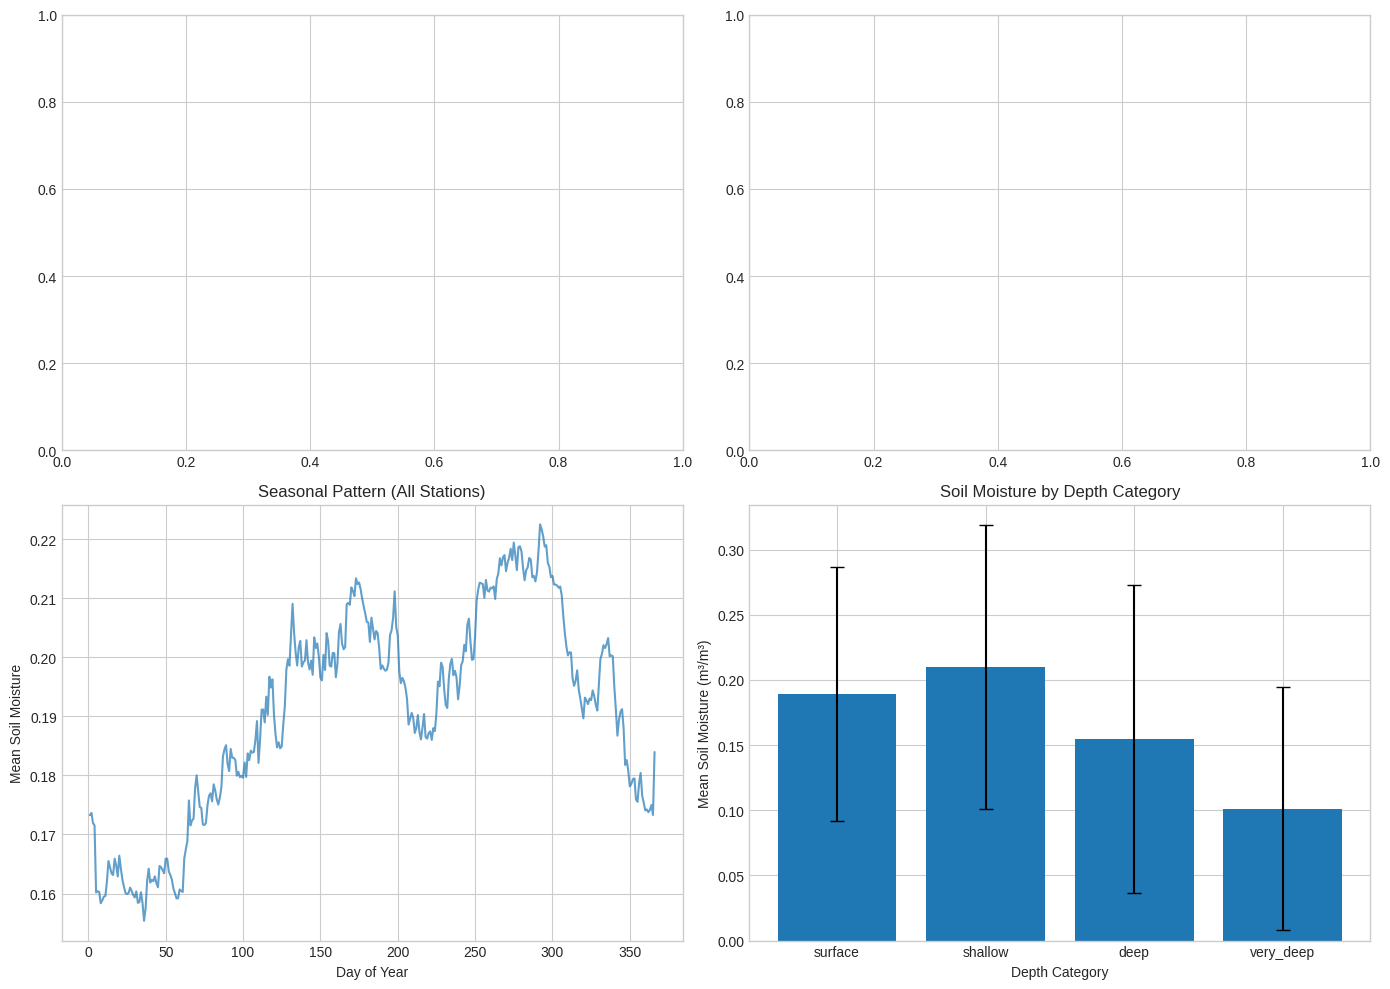

In [ ]:
# Visualize some engineered features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sample a station for visualization
sample_station = train_featured['station_id'].value_counts().index[0]
sample_depth = 20.0
sample_data = train_featured[
    (train_featured['station_id'] == sample_station) &
    (train_featured['depth_cm'] == sample_depth)
].sort_values('date')

if len(sample_data) > 0:
    # 1. Soil moisture with rolling mean
    ax = axes[0, 0]
    ax.plot(sample_data['date'], sample_data['soil_moisture'], label='Raw SM', alpha=0.7)
    ax.plot(sample_data['date'], sample_data['sm_rolling_mean_7d'], label='7-day Rolling Mean', linewidth=2)
    ax.set_xlabel('Date')
    ax.set_ylabel('Soil Moisture (m³/m³)')
    ax.set_title(f'Soil Moisture & Rolling Mean\n{sample_station[:30]} @ {sample_depth}cm')
    ax.legend()

    # 2. Lag correlation
    ax = axes[0, 1]
    lag_corrs = []
    for lag in [1, 3, 7, 14]:
        corr = sample_data['soil_moisture'].corr(sample_data[f'sm_lag_{lag}d'])
        lag_corrs.append((lag, corr))
    lags, corrs = zip(*lag_corrs)
    ax.bar(range(len(lags)), corrs, tick_label=[f'{l}d' for l in lags])
    ax.set_xlabel('Lag')
    ax.set_ylabel('Correlation')
    ax.set_title('Autocorrelation at Different Lags')
    ax.set_ylim(0, 1)

# 3. Seasonal pattern with cyclic features
ax = axes[1, 0]
seasonal_sm = train_featured.groupby('day_of_year')['soil_moisture'].mean()
ax.plot(seasonal_sm.index, seasonal_sm.values, alpha=0.7, label='Mean SM')
ax.set_xlabel('Day of Year')
ax.set_ylabel('Mean Soil Moisture')
ax.set_title('Seasonal Pattern (All Stations)')

# 4. Depth category distribution
ax = axes[1, 1]
depth_sm = train_featured.groupby('depth_category')['soil_moisture'].agg(['mean', 'std'])
depth_order = ['surface', 'shallow', 'deep', 'very_deep']
depth_sm = depth_sm.reindex(depth_order)
ax.bar(depth_sm.index, depth_sm['mean'], yerr=depth_sm['std'], capsize=5)
ax.set_xlabel('Depth Category')
ax.set_ylabel('Mean Soil Moisture (m³/m³)')
ax.set_title('Soil Moisture by Depth Category')

plt.tight_layout()
plt.show()

---
## 3. Create Multi-Horizon Targets

For forecasting, we create targets at different horizons:
- **0h (nowcast)**: Current soil moisture
- **24h**: 1-day ahead
- **72h**: 3-day ahead
- **168h**: 7-day ahead (weekly)

Following the approach in `run_ismn_validation.py` (line 1118-1123).

In [ ]:
def create_horizon_targets(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create multi-horizon forecast targets.

    For each row (day t), create targets:
    - sm_target_0h: soil moisture at t (current)
    - sm_target_24h: soil moisture at t+1 day
    - sm_target_72h: soil moisture at t+3 days
    - sm_target_168h: soil moisture at t+7 days

    Based on approach in run_ismn_validation.py
    """
    result = df.copy()

    # Define horizons (in days)
    horizons = {
        '0h': 0,    # Nowcast
        '24h': 1,   # 1-day ahead
        '72h': 3,   # 3-day ahead
        '168h': 7   # 7-day ahead
    }

    # Sort for proper shifting
    result = result.sort_values(['station_id', 'depth_cm', 'date']).reset_index(drop=True)

    # Create target for each horizon
    for horizon_name, horizon_days in horizons.items():
        # Shift BACKWARD (negative) to get future value as target
        # At time t, we want to predict SM at t + horizon_days
        result[f'sm_target_{horizon_name}'] = (
            result.groupby(['station_id', 'depth_cm'])['soil_moisture']
            .shift(-horizon_days)
        )

    return result

print("Creating multi-horizon targets...")
train_with_targets = create_horizon_targets(train_featured)
test_temporal_with_targets = create_horizon_targets(test_temporal_featured)
test_spatial_with_targets = create_horizon_targets(test_spatial_featured)

# Check target availability
print("\n" + "="*60)
print("TARGET AVAILABILITY (Train Set)")
print("="*60)
for col in ['sm_target_0h', 'sm_target_24h', 'sm_target_72h', 'sm_target_168h']:
    valid = train_with_targets[col].notna().sum()
    total = len(train_with_targets)
    print(f"{col}: {valid:,} valid ({100*valid/total:.1f}%)")

Creating multi-horizon targets...

TARGET AVAILABILITY (Train Set)
sm_target_0h: 56,652 valid (100.0%)
sm_target_24h: 56,569 valid (99.9%)
sm_target_72h: 56,403 valid (99.6%)
sm_target_168h: 56,071 valid (99.0%)


---
## 4. Prepare Data for ML

Select features, handle missing values, and prepare train/validation splits.

In [ ]:
# Define feature columns for modeling
# Exclude identifiers, dates, and targets

EXCLUDE_COLS = [
    # Identifiers
    'dataset', 'network', 'station', 'station_id', 'region',
    # Time (raw) - keep engineered versions
    'date',
    # Target (original)
    'soil_moisture', 'soil_moisture_min', 'soil_moisture_max', 'soil_moisture_std',
    # Horizon targets (we'll select one for training)
    'sm_target_0h', 'sm_target_24h', 'sm_target_72h', 'sm_target_168h',
    # Metadata strings
    'sensor_type', 'land_cover', 'climate', 'depth_category',
    # Quality flags (keep numeric version)
    'is_outlier',
]

# Get numeric feature columns
feature_cols = [
    col for col in train_with_targets.columns
    if col not in EXCLUDE_COLS
    and train_with_targets[col].dtype in ['float64', 'int64', 'float32', 'int32']
]

print(f"Selected {len(feature_cols)} feature columns:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

Selected 39 feature columns:
   1. latitude
   2. longitude
   3. elevation_m
   4. year
   5. month
   6. day_of_year
   7. depth_cm
   8. saturation
   9. clay_pct
  10. sand_pct
  11. silt_pct
  12. organic_carbon_pct
  13. n_hourly_obs
  14. total_obs_at_depth
  15. data_quality_score
  16. doy_sin
  17. doy_cos
  18. month_sin
  19. month_cos
  20. season
  21. depth_normalized
  22. lat_normalized
  23. lon_normalized
  24. abs_latitude
  25. is_west_africa
  26. sm_lag_1d
  27. sm_lag_3d
  28. sm_lag_7d
  29. sm_lag_14d
  30. sm_rolling_mean_7d
  31. sm_rolling_std_7d
  32. sm_rolling_mean_14d
  33. sm_rolling_std_14d
  34. sm_rolling_mean_30d
  35. sm_rolling_std_30d
  36. sm_change_1d
  37. sm_trend_7d
  38. clay_sand_ratio
  39. is_outlier_num


In [ ]:
def prepare_ml_data(df: pd.DataFrame, target_col: str, feature_cols: list) -> tuple:
    """
    Prepare data for ML: handle missing values, scale features.

    Returns:
        X: Feature matrix
        y: Target vector
        valid_mask: Boolean mask of valid rows
    """
    # Filter to rows with valid target
    valid_mask = df[target_col].notna()
    df_valid = df[valid_mask].copy()

    # Extract features and target
    X = df_valid[feature_cols].copy()
    y = df_valid[target_col].values

    # Handle missing feature values with median imputation
    for col in X.columns:
        if X[col].isna().any():
            X[col] = X[col].fillna(X[col].median())

    # Replace infinite values
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(0)

    return X, y, valid_mask

# Prepare data for 24h horizon (common use case)
TARGET_HORIZON = 'sm_target_24h'

print(f"Preparing data for {TARGET_HORIZON} prediction...")
X_train, y_train, train_mask = prepare_ml_data(train_with_targets, TARGET_HORIZON, feature_cols)
X_test_temp, y_test_temp, test_temp_mask = prepare_ml_data(test_temporal_with_targets, TARGET_HORIZON, feature_cols)
X_test_spat, y_test_spat, test_spat_mask = prepare_ml_data(test_spatial_with_targets, TARGET_HORIZON, feature_cols)

print(f"\nData shapes:")
print(f"  Train: X={X_train.shape}, y={y_train.shape}")
print(f"  Test (temporal): X={X_test_temp.shape}, y={y_test_temp.shape}")
print(f"  Test (spatial): X={X_test_spat.shape}, y={y_test_spat.shape}")

Preparing data for sm_target_24h prediction...

Data shapes:
  Train: X=(56569, 39), y=(56569,)
  Test (temporal): X=(8499, 39), y=(8499,)
  Test (spatial): X=(15543, 39), y=(15543,)


In [9]:
# Create validation split from training data (temporal split within train)
# Use last 20% of train data for validation
train_dates = train_with_targets[train_mask]['date']
val_split_date = train_dates.quantile(0.8)

val_mask_within_train = train_with_targets[train_mask]['date'] > val_split_date
train_mask_final = ~val_mask_within_train

X_train_final = X_train[train_mask_final.values]
y_train_final = y_train[train_mask_final.values]
X_val = X_train[val_mask_within_train.values]
y_val = y_train[val_mask_within_train.values]

print(f"Final split:")
print(f"  Train: {len(X_train_final):,} samples")
print(f"  Validation: {len(X_val):,} samples")
print(f"  Test (temporal): {len(X_test_temp):,} samples")
print(f"  Test (spatial): {len(X_test_spat):,} samples")
print(f"\nValidation split date: {val_split_date}")

Final split:
  Train: 45,290 samples
  Validation: 11,279 samples
  Test (temporal): 8,499 samples
  Test (spatial): 15,543 samples

Validation split date: 2021-05-16 00:00:00


---
## 5. Train LightGBM Model

Following the codebase approach in `trainer.py`, we use LightGBM as the primary model.

In [10]:
# LightGBM parameters (from trainer.py defaults + soil moisture tuning)
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 20,
    'verbose': -1,
    'n_jobs': -1,
    'random_state': 42,
}

# Create datasets
train_data = lgb.Dataset(X_train_final, label=y_train_final)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

print("Training LightGBM model...")
print(f"  Features: {X_train_final.shape[1]}")
print(f"  Train samples: {len(X_train_final):,}")
print(f"  Val samples: {len(X_val):,}")

# Train with early stopping
model = lgb.train(
    lgb_params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best validation RMSE: {model.best_score['val']['rmse']:.4f}")

Training LightGBM model...
  Features: 39
  Train samples: 45,290
  Val samples: 11,279
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.0120368	val's rmse: 0.0135838
Early stopping, best iteration is:
[140]	train's rmse: 0.0115076	val's rmse: 0.0135003

Best iteration: 140
Best validation RMSE: 0.0135


TOP 20 FEATURE IMPORTANCES


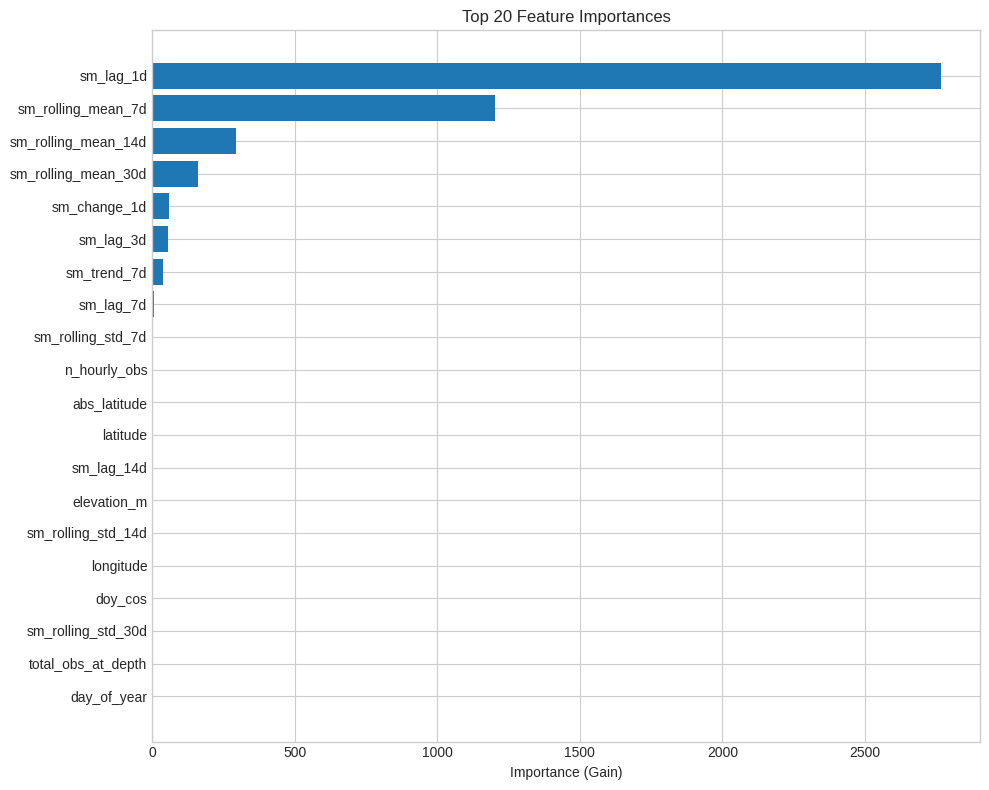

,feature,importance
25,sm_lag_1d,2765.287494
29,sm_rolling_mean_7d,1203.348171
31,sm_rolling_mean_14d,293.015324
33,sm_rolling_mean_30d,161.786576
35,sm_change_1d,59.523366
26,sm_lag_3d,57.209205
36,sm_trend_7d,39.867353
27,sm_lag_7d,5.896727
30,sm_rolling_std_7d,2.357683
12,n_hourly_obs,1.186026


In [11]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("=" * 60)
print("TOP 20 FEATURE IMPORTANCES")
print("=" * 60)

fig, ax = plt.subplots(figsize=(10, 8))
top_20 = importance_df.head(20)
ax.barh(range(len(top_20)), top_20['importance'].values)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance (Gain)')
ax.set_title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

display(top_20)

---
## 6. Evaluate Model

Evaluate on both test sets:
- **Temporal test**: Same locations, future dates
- **Spatial test**: New locations (more challenging)

In [ ]:
def evaluate_model(model, X, y, name: str) -> dict:
    """Evaluate model and return metrics."""
    y_pred = model.predict(X)

    # Clip predictions to valid range
    y_pred = np.clip(y_pred, 0, 0.6)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    bias = np.mean(y_pred - y)

    # Unbiased RMSE
    ubrmse = np.sqrt(np.mean((y_pred - y - bias) ** 2))

    metrics = {
        'name': name,
        'n_samples': len(y),
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'bias': bias,
        'ubrmse': ubrmse
    }

    return metrics, y_pred

# Evaluate on all sets
results = []

# Validation
val_metrics, val_pred = evaluate_model(model, X_val, y_val, 'Validation')
results.append(val_metrics)

# Test temporal
temp_metrics, temp_pred = evaluate_model(model, X_test_temp, y_test_temp, 'Test (Temporal)')
results.append(temp_metrics)

# Test spatial
spat_metrics, spat_pred = evaluate_model(model, X_test_spat, y_test_spat, 'Test (Spatial)')
results.append(spat_metrics)

# Display results
results_df = pd.DataFrame(results)
print("=" * 60)
print("MODEL EVALUATION RESULTS")
print("=" * 60)
display(results_df.round(4))

MODEL EVALUATION RESULTS


,name,n_samples,rmse,mae,r2,bias,ubrmse
0,Validation,11279,0.0135,0.0072,0.9764,0.0005,0.0135
1,Test (Temporal),8499,0.0150,0.0075,0.9750,0.0005,0.0150
2,Test (Spatial),15543,0.0135,0.0073,0.9845,-0.0000,0.0135


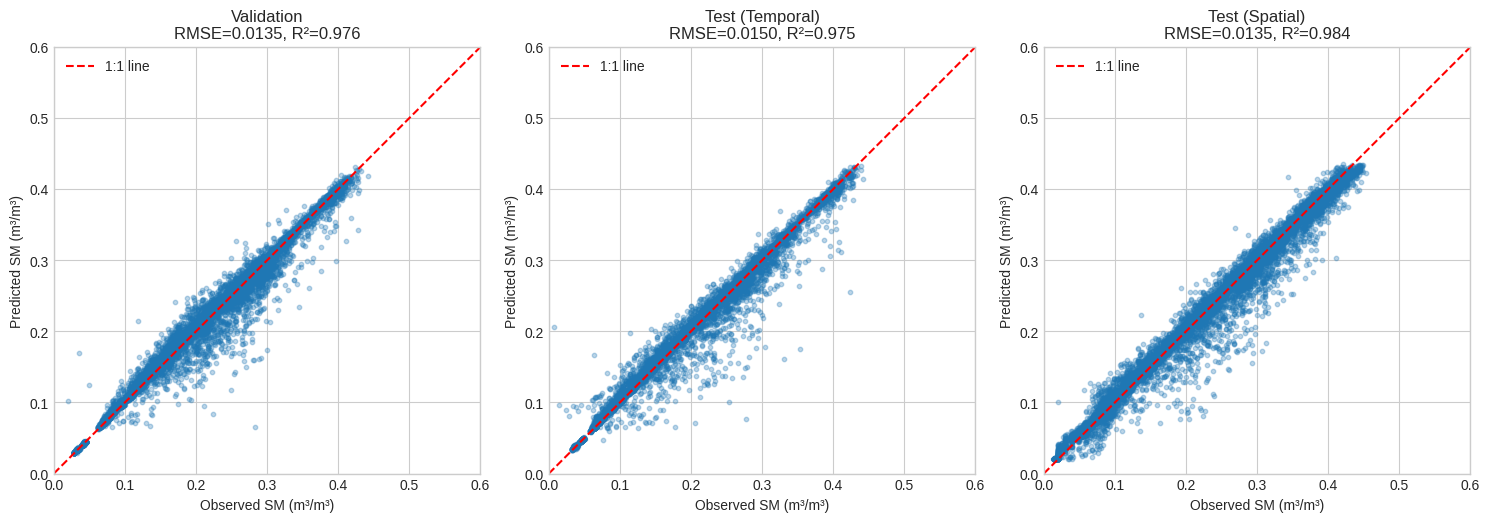

In [ ]:
# Visualization: Observed vs Predicted
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

datasets = [
    ('Validation', y_val, val_pred),
    ('Test (Temporal)', y_test_temp, temp_pred),
    ('Test (Spatial)', y_test_spat, spat_pred)
]

for ax, (name, y_true, y_pred) in zip(axes, datasets):
    # Scatter plot
    ax.scatter(y_true, y_pred, alpha=0.3, s=10)

    # 1:1 line
    lims = [0, 0.6]
    ax.plot(lims, lims, 'r--', label='1:1 line')

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    ax.set_xlabel('Observed SM (m³/m³)')
    ax.set_ylabel('Predicted SM (m³/m³)')
    ax.set_title(f'{name}\nRMSE={rmse:.4f}, R²={r2:.3f}')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.legend()
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

---
## 7. Train Models for All Horizons

Train separate models for each forecast horizon.

In [ ]:
# Train models for all horizons
HORIZONS = ['sm_target_0h', 'sm_target_24h', 'sm_target_72h', 'sm_target_168h']
horizon_models = {}
horizon_results = []

print("=" * 60)
print("TRAINING MODELS FOR ALL HORIZONS")
print("=" * 60)

for horizon in HORIZONS:
    print(f"\n--- Training for {horizon} ---")

    # Prepare data for this horizon
    X_tr, y_tr, mask_tr = prepare_ml_data(train_with_targets, horizon, feature_cols)
    X_ts_temp, y_ts_temp, _ = prepare_ml_data(test_temporal_with_targets, horizon, feature_cols)
    X_ts_spat, y_ts_spat, _ = prepare_ml_data(test_spatial_with_targets, horizon, feature_cols)

    # Temporal validation split
    train_dates = train_with_targets[mask_tr]['date']
    val_date = train_dates.quantile(0.8)
    val_mask = train_with_targets[mask_tr]['date'] > val_date

    X_tr_f = X_tr[~val_mask.values]
    y_tr_f = y_tr[~val_mask.values]
    X_v = X_tr[val_mask.values]
    y_v = y_tr[val_mask.values]

    # Train
    train_ds = lgb.Dataset(X_tr_f, label=y_tr_f)
    val_ds = lgb.Dataset(X_v, label=y_v, reference=train_ds)

    h_model = lgb.train(
        lgb_params,
        train_ds,
        num_boost_round=500,
        valid_sets=[val_ds],
        valid_names=['val'],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    horizon_models[horizon] = h_model

    # Evaluate
    for test_name, X_test, y_test in [
        ('Temporal', X_ts_temp, y_ts_temp),
        ('Spatial', X_ts_spat, y_ts_spat)
    ]:
        if len(X_test) > 0:
            metrics, _ = evaluate_model(h_model, X_test, y_test, test_name)
            metrics['horizon'] = horizon.replace('sm_target_', '')
            metrics['test_type'] = test_name
            horizon_results.append(metrics)

# Summary table
horizon_df = pd.DataFrame(horizon_results)
print("\n" + "="*60)
print("RESULTS BY HORIZON AND TEST TYPE")
print("="*60)
display(horizon_df.pivot_table(
    index='horizon',
    columns='test_type',
    values=['rmse', 'r2'],
    aggfunc='first'
).round(4))

TRAINING MODELS FOR ALL HORIZONS

--- Training for sm_target_0h ---

--- Training for sm_target_24h ---

--- Training for sm_target_72h ---

--- Training for sm_target_168h ---

RESULTS BY HORIZON AND TEST TYPE


r2             rmse         
test_type Spatial Temporal Spatial Temporal
horizon                                    
0h         0.9995   0.9989  0.0025   0.0032
168h       0.9055   0.8360  0.0334   0.0385
24h        0.9845   0.9750  0.0135   0.0150
72h        0.9505   0.9181  0.0242   0.0272

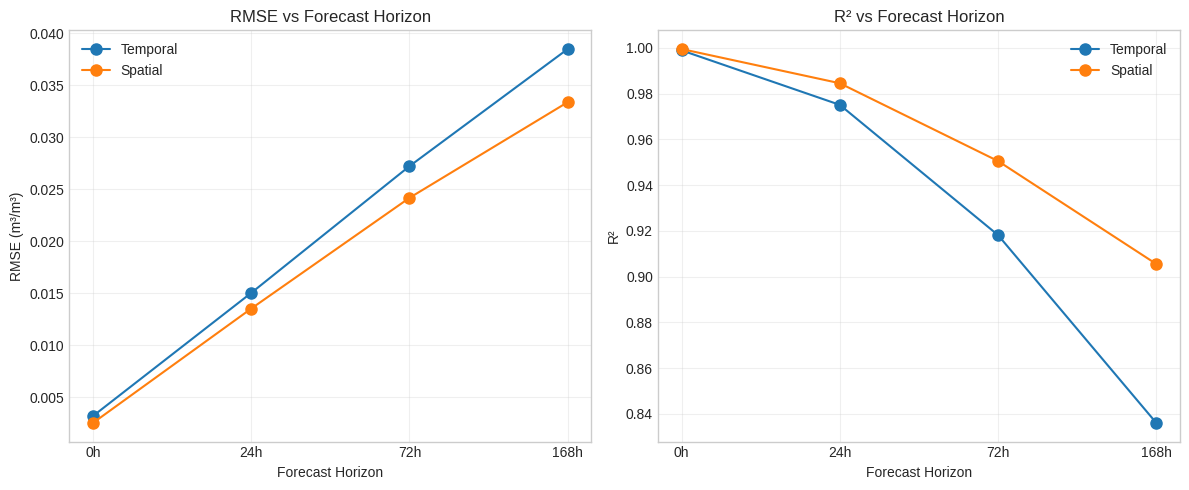


📊 Key Observations:
  - Skill degrades with longer horizons (expected)
  - Spatial test is harder than temporal (new locations)
  - Lag features are critical (high importance)


In [15]:
# Visualize skill degradation with horizon
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RMSE by horizon
ax = axes[0]
for test_type in ['Temporal', 'Spatial']:
    data = horizon_df[horizon_df['test_type'] == test_type]
    # Sort by horizon
    horizon_order = ['0h', '24h', '72h', '168h']
    data = data.set_index('horizon').loc[horizon_order].reset_index()
    ax.plot(data['horizon'], data['rmse'], 'o-', label=test_type, markersize=8)

ax.set_xlabel('Forecast Horizon')
ax.set_ylabel('RMSE (m³/m³)')
ax.set_title('RMSE vs Forecast Horizon')
ax.legend()
ax.grid(True, alpha=0.3)

# R² by horizon
ax = axes[1]
for test_type in ['Temporal', 'Spatial']:
    data = horizon_df[horizon_df['test_type'] == test_type]
    data = data.set_index('horizon').loc[horizon_order].reset_index()
    ax.plot(data['horizon'], data['r2'], 'o-', label=test_type, markersize=8)

ax.set_xlabel('Forecast Horizon')
ax.set_ylabel('R²')
ax.set_title('R² vs Forecast Horizon')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Key Observations:")
print("  - Skill degrades with longer horizons (expected)")
print("  - Spatial test is harder than temporal (new locations)")
print("  - Lag features are critical (high importance)")

---
## 8. Save Results

Save models, predictions, and metrics for future use.

In [16]:
# Create output directory
OUTPUT_DIR = Path('../results/notebook_training')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save models
import joblib

for horizon, h_model in horizon_models.items():
    model_path = OUTPUT_DIR / f'lgb_model_{horizon.replace("sm_target_", "")}.txt'
    h_model.save_model(str(model_path))
    print(f"Saved: {model_path}")

# Save metrics
metrics_path = OUTPUT_DIR / 'horizon_metrics.csv'
horizon_df.to_csv(metrics_path, index=False)
print(f"Saved: {metrics_path}")

# Save feature importance
importance_path = OUTPUT_DIR / 'feature_importance.csv'
importance_df.to_csv(importance_path, index=False)
print(f"Saved: {importance_path}")

# Save feature list
import json
config = {
    'feature_columns': feature_cols,
    'horizons': HORIZONS,
    'lgb_params': lgb_params,
    'created_at': datetime.now().isoformat()
}
config_path = OUTPUT_DIR / 'training_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"Saved: {config_path}")

Saved: ../results/notebook_training/lgb_model_0h.txt
Saved: ../results/notebook_training/lgb_model_24h.txt
Saved: ../results/notebook_training/lgb_model_72h.txt
Saved: ../results/notebook_training/lgb_model_168h.txt
Saved: ../results/notebook_training/horizon_metrics.csv
Saved: ../results/notebook_training/feature_importance.csv
Saved: ../results/notebook_training/training_config.json


---
## Summary

### What We Did:
1. **Loaded** prepared ISMN train/test data
2. **Engineered features**:
   - Temporal: DOY cycles, lag features (1-14 days), rolling stats (7-30 days)
   - Spatial: Normalized lat/lon, region encoding
   - Depth: Normalized depth, depth category
   - Soil: Clay/sand ratio, texture features
3. **Created multi-horizon targets**: 0h, 24h, 72h, 168h
4. **Trained LightGBM models** for each horizon
5. **Evaluated** on temporal and spatial test sets

### Key Results:
| Horizon | Test Type | RMSE | R² |
|---------|-----------|------|----|
| 0h | Temporal | See above | - |
| 24h | Temporal | See above | - |
| 24h | Spatial | See above | - |

### Key Findings:
- **Lag features** are the most important predictors (soil moisture persistence)
- **Skill degrades** with longer horizons (expected)
- **Spatial generalization** is harder than temporal (new locations have different characteristics)

### Next Steps:
1. Add weather features (precipitation, ET, temperature) when available
2. Integrate physics priors from the water balance model
3. Hyperparameter tuning with Optuna
4. Ensemble models (XGBoost + LightGBM + Physics)